<a href="https://colab.research.google.com/github/Navya28-khanna/ML_LAB/blob/main/Lab9_RF_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_excel("german credit.xlsx")
df.head()

,Status of existing checking account,Duration,Credit history,Purpose,Column1,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker,No. Of children
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
#basic EDA
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Status of existing checking account                       1000 non-null   object
 1   Duration                                                  1000 non-null   int64 
 2   Credit history                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Column1                                                   1000 non-null   int64 
 5   Savings account/bonds                                     1000 non-null   object
 6   Present employment since                                  1000 non-null   object
 7   Installment rate in percentage of disposable income       1000 non-null   int64 
 8   Personal status and sex      

,0
Status of existing checking account,0
Duration,0
Credit history,0
Purpose,0
Column1,0
Savings account/bonds,0
Present employment since,0
Installment rate in percentage of disposable income,0
Personal status and sex,0
Other debtors / guarantors,0


In [14]:
df.fillna(df.mode().iloc[0], inplace=True)

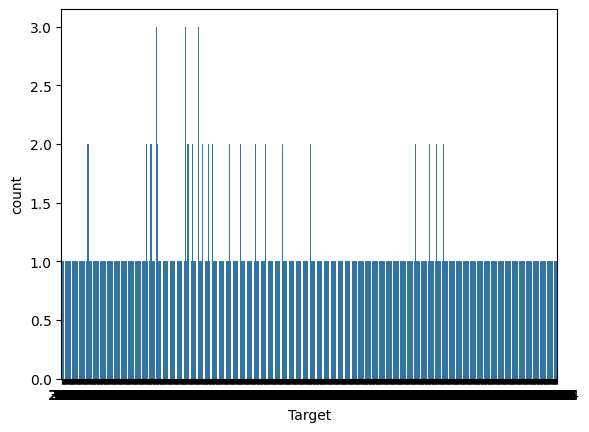

In [9]:
sns.countplot(x="Target", data=df)
plt.show()

In [10]:
df.fillna(df.mode().iloc[0], inplace=True)

In [13]:
#encode categorial data
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [16]:
#feature scaling
X = df.drop("Target", axis=1)
y = df["Target"]

In [17]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
#prediction and evaluation
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.0
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

         276       0.00      0.00      0.00       1.0
         368       0.00      0.00      0.00       1.0
         385       0.00      0.00      0.00       1.0
         428       0.00      0.00      0.00       0.0
         433       0.00      0.00      0.00       1.0
         448       0.00      0.00      0.00       0.0
         458       0.00      0.00      0.00       1.0
         484       0.00      0.00      0.00       1.0
         518       0.00      0.00      0.00       1.0
         522       0.00      0.00      0.00       0.0
         585       0.00      0.00      0.00       1.0
         601       0.00      0.00      0.00       1.0
         609       0.00      0.00      0.00       1.0
         626       0.00      0.00      0.00       1.0
         660       0.00      0.00      0.00       1.0
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [22]:
from sklearn.model_selection import StratifiedKFold
params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

cv = StratifiedKFold(n_splits=3)

grid = GridSearchCV(RandomForestClassifier(), params, cv=cv)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'max_depth': None, 'n_estimators': 50}


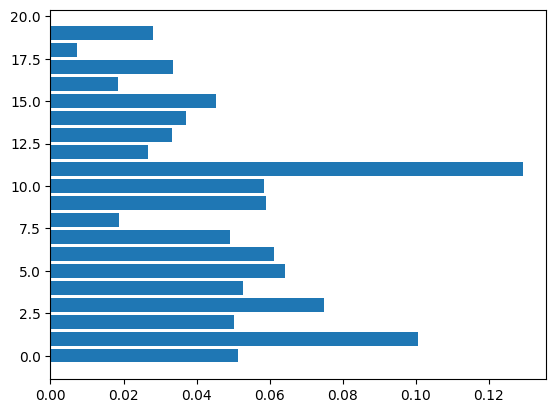

In [23]:
rf_best = grid.best_estimator_

importances = rf_best.feature_importances_

plt.barh(range(len(importances)), importances)
plt.show()

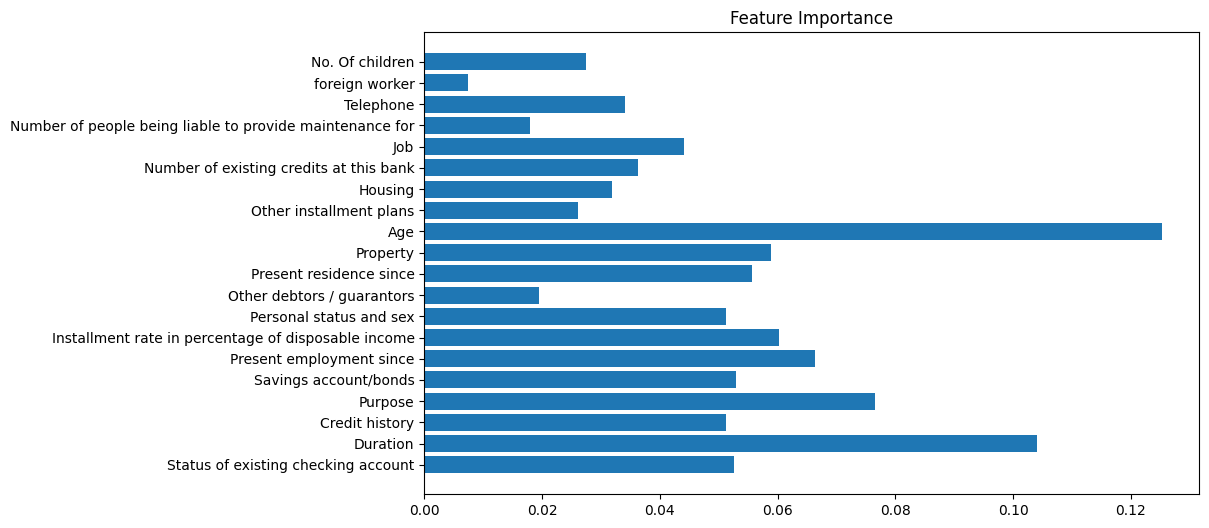

In [24]:
importances = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

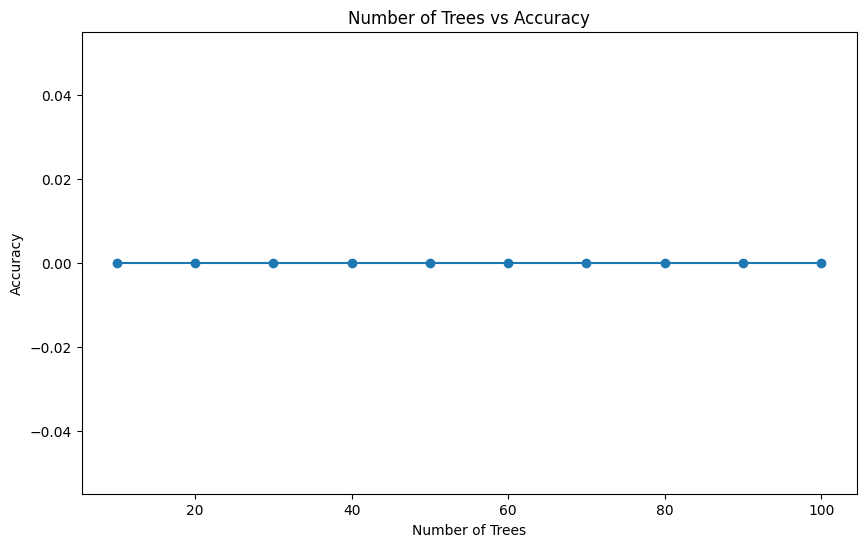

In [25]:
ntree = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
accuracy = []

for n in ntree:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy.append(acc)

# Plot
plt.figure(figsize=(10,6))
plt.plot(ntree, accuracy, marker='o')
plt.title("Number of Trees vs Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()